In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# NLP
import re
import string

# Visualization (for EDA later)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [4]:
test.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


In [5]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [6]:
train.shape

(159571, 8)

In [7]:
test.shape

(153164, 2)

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [9]:
train.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [10]:
test.isnull().sum()

,0
id,0
comment_text,0


In [11]:
target_cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

train[target_cols].sum()

,0
toxic,15294
severe_toxic,1595
obscene,8449
threat,478
insult,7877
identity_hate,1405


In [12]:
train['num_labels'] = train[target_cols].sum(axis=1)
train['num_labels'].value_counts()

,count
num_labels,
0,143346
1,6360
3,4209
2,3480
4,1760
5,385
6,31


In [ ]:
train['comment_text'].isnull().sum()

np.int64(0)

In [13]:
train['comment_length'] = train['comment_text'].apply(len)

train['comment_length'].describe()

,comment_length
count,159571.000000
mean,394.073221
std,590.720282
min,6.000000
25%,96.000000
50%,205.000000
75%,435.000000
max,5000.000000


In [14]:
train['is_toxic'] = train[target_cols].sum(axis=1) > 0

train.groupby('is_toxic')['comment_length'].mean()

,comment_length
is_toxic,
False,404.347174
True,303.304037


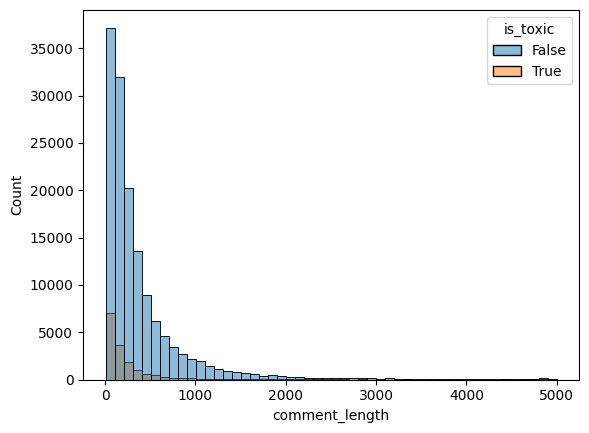

In [15]:
plt.figure()
sns.histplot(data=train, x='comment_length', hue='is_toxic', bins=50)
plt.show()

In [33]:
def clean_text(text):
  text = text.lower()

  text = re.sub(r'http\S+','',text)
  text = re.sub(r'<[^>]*>','', text) # Changed this line to correctly remove HTML tags
  text = re.sub(r'\d+','',text)
  text = text.strip()
  text = text.translate(str.maketrans('', '', string.punctuation))
  return text

In [17]:
train['clean_text'] = train['comment_text'].apply(clean_text)
test['clean_text'] = test['comment_text'].apply(clean_text)

In [ ]:
train[['comment_text', 'clean_text']].head()

,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,
1,D'aww! He matches this background colour I'm s...,
2,"Hey man, I'm really not trying to edit war. It...",
3,"""\nMore\nI can't make any real suggestions on ...",
4,"You, sir, are my hero. Any chance you remember...",


In [26]:
import pandas as pd
import numpy as np
import re
import string

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.metrics import classification_report

In [19]:
max_words = 20000
tokenizer = Tokenizer(num_words=max_words)

tokenizer.fit_on_texts(train['clean_text'])

X_train_seq = tokenizer.texts_to_sequences(train['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(test['clean_text'])

In [20]:
max_len = 200

X_train = pad_sequences(X_train_seq, maxlen=max_len)
X_test = pad_sequences(X_test_seq, maxlen=max_len)

In [21]:
y = train[target_cols]

In [22]:
sample_weights = y.sum(axis=1) + 1

In [25]:
model = Sequential()

model.add(Embedding(input_dim=20000, output_dim=128))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(6, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    X_train,
    y,
    epochs=2,
    batch_size=128,
    validation_split=0.1,
    sample_weight=sample_weights
)

Epoch 1/2
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 409s 362ms/step - accuracy: 0.6928 - loss: 0.4070 - val_accuracy: 0.9940 - val_loss: 0.3815
Epoch 2/2
1122/1122 ━━━━━━━━━━━━━━━━━━━━ 444s 364ms/step - accuracy: 0.9501 - loss: 0.3836 - val_accuracy: 0.9940 - val_loss: 0.3814


In [28]:
y_pred = model.predict(X_train)

4987/4987 ━━━━━━━━━━━━━━━━━━━━ 157s 31ms/step


In [29]:
y_pred_binary = (y_pred > 0.3).astype(int)

In [30]:
print(classification_report(y, y_pred_binary, target_names=target_cols))

               precision    recall  f1-score   support

        toxic       0.00      0.00      0.00     15294
 severe_toxic       0.00      0.00      0.00      1595
      obscene       0.00      0.00      0.00      8449
       threat       0.00      0.00      0.00       478
       insult       0.00      0.00      0.00      7877
identity_hate       0.00      0.00      0.00      1405

    micro avg       0.00      0.00      0.00     35098
    macro avg       0.00      0.00      0.00     35098
 weighted avg       0.00      0.00      0.00     35098
  samples avg       0.00      0.00      0.00     35098



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000)

X_train_tfidf = tfidf.fit_transform(train['clean_text'])

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

# Initialize the base classifier (Logistic Regression)
classifier = LogisticRegression(solver='sag', random_state=42, n_jobs=-1, max_iter=200)

# Wrap the classifier in MultiOutputClassifier
multi_output_classifier = MultiOutputClassifier(classifier)

# Train the model
print("Training the MultiOutputClassifier...")
multi_output_classifier.fit(X_train_tfidf, y)
print("Training complete.")

Training the MultiOutputClassifier...
Training complete.


In [38]:
X_test_tfidf = tfidf.transform(test['clean_text'])

In [39]:
print(X_test_tfidf.shape)

(153164, 20000)


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000)

X_train_tfidf = tfidf.fit_transform(train['clean_text'])

In [36]:
train[['comment_text', 'clean_text']].head()

,comment_text,clean_text
0,Explanation\nWhy the edits made under my usern...,explanation\nwhy the edits made under my usern...
1,D'aww! He matches this background colour I'm s...,daww he matches this background colour im seem...
2,"Hey man, I'm really not trying to edit war. It...",hey man im really not trying to edit war its j...
3,"""\nMore\nI can't make any real suggestions on ...",\nmore\ni cant make any real suggestions on im...
4,"You, sir, are my hero. Any chance you remember...",you sir are my hero any chance you remember wh...


In [35]:
train['clean_text'] = train['comment_text'].apply(clean_text)
test['clean_text'] = test['comment_text'].apply(clean_text)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier

lr = LogisticRegression(max_iter=1000)

model_lr = MultiOutputClassifier(lr)

model_lr.fit(X_train_tfidf, y)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000))

In [43]:
y_pred_lr = model_lr.predict(X_train_tfidf)

In [44]:
print(classification_report(y, y_pred_lr, target_names=target_cols))

               precision    recall  f1-score   support

        toxic       0.93      0.65      0.77     15294
 severe_toxic       0.62      0.27      0.37      1595
      obscene       0.92      0.67      0.78      8449
       threat       0.73      0.15      0.25       478
       insult       0.85      0.57      0.68      7877
identity_hate       0.73      0.21      0.32      1405

    micro avg       0.89      0.60      0.72     35098
    macro avg       0.80      0.42      0.53     35098
 weighted avg       0.88      0.60      0.71     35098
  samples avg       0.06      0.05      0.05     35098



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
import pickle

# Save vectorizer
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save model
with open('model_lr.pkl', 'wb') as f:
    pickle.dump(model_lr, f)

In [46]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.4 MB/s eta 0:00:00


In [48]:
%%writefile app.py
import streamlit as st
import pickle

# Load saved TF-IDF and model
with open('tfidf.pkl', 'rb') as f:
    tfidf = pickle.load(f)

with open('model_lr.pkl', 'rb') as f:
    model = pickle.load(f)

# Labels
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

# Title
st.title("💬 Toxic Comment Detection App")

st.write("Detect whether a comment is toxic or not using Machine Learning")

# Input box
user_input = st.text_area("Enter your comment here:")

# Predict button
if st.button("Predict"):

    if user_input.strip() != "":

        # Transform input
        input_vec = tfidf.transform([user_input])

        # Prediction
        prediction = model.predict(input_vec)[0]

        st.subheader("Prediction Results:")

        # Show results nicely
        for label, val in zip(labels, prediction):
            if val == 1:
                st.error(f"{label.upper()} ⚠️")
            else:
                st.success(f"{label}: Safe")

    else:
        st.warning("Please enter some text")

Overwriting app.py


In [49]:
!streamlit run app.py &>/dev/null &

In [54]:
!ngrok config add-authtoken 3AJ3EFaoEmXcNxOY73DR4wOVWGy_438YU4oC2A9VncwHRFeeU

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [55]:
from pyngrok import ngrok
ngrok.connect(8501)

<NgrokTunnel: "https://shira-refreshful-horace.ngrok-free.dev" -> "http://localhost:8501">

In [ ]:
from pyngrok import ngrok

# Replace 'YOUR_AUTH_TOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("YOUR_AUTH_TOKEN")
ngrok.connect(8501)